# Student Performance Predictor — Exploratory Data Analysis

This notebook explores the **Student Performance** dataset before any preprocessing or machine-learning model is built.

### Goals
- Understand the shape and structure of the dataset.
- Identify numerical and categorical features.
- Check data quality, including missing values and duplicates.
- Explore the target variable `G3` (final grade).
- Study relationships between student characteristics and final performance.
- Identify important modeling considerations, especially the role of `G1` and `G2`.

> **Target:** `G3`, the student's final grade on a 0–20 scale.


## 1. Import libraries

We begin by importing the libraries used for data manipulation, numerical operations, visualization, and file-path handling.  
`pandas` and `numpy` support data analysis, while `matplotlib` and `seaborn` are used to create the EDA charts.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# A consistent visual style for the notebook
sns.set_theme(style="whitegrid")


## 2. Load the dataset

The dataset is stored in `data/raw/`. Because this notebook is inside the `notebooks/` directory, `..` moves one level up to the project root.

The CSV uses a semicolon (`;`) as its separator, so we specify `sep=";"` when reading it.


In [2]:
DATA_PATH = Path("../data/raw/student-mat.csv")

df = pd.read_csv(DATA_PATH, sep=";")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 3. Dataset overview

Before cleaning or transforming anything, we inspect the dataset's dimensions and column names.  
This gives us a quick understanding of how many observations and features we are working with.


In [3]:
df.shape

(395, 33)

In [4]:
df.columns.tolist()

['school',
 'sex',
 'age',
 'address',
 'famsize',
 'Pstatus',
 'Medu',
 'Fedu',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health',
 'absences',
 'G1',
 'G2',
 'G3']

**Observation:** The dataset contains **395 students and 33 columns**. The columns include demographic, family, school, lifestyle, and academic-performance information.


## 4. Data types and feature groups

`df.info()` shows the number of non-null values and the data type of every column.  
We then separate columns into numerical and categorical groups because they will require different preprocessing strategies later.


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [6]:
df.dtypes

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

In [7]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Categorical columns:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


**Observation:** There are **16 numerical columns** and **17 categorical columns**.  
Some integer-valued features such as `studytime`, `traveltime`, and `health` are better interpreted as **ordinal variables** rather than continuous measurements because they represent ordered levels.


## 5. Data-quality checks

Before EDA, we check for two common data-quality problems:

- **Missing values:** incomplete observations may require imputation or removal.
- **Duplicate rows:** repeated observations can distort statistics and model training.

We do not remove or fill anything unless the data actually requires it.


In [8]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
df.duplicated().sum()

np.int64(0)

**Observation:** The dataset contains **0 missing values and 0 duplicate rows**, so no missing-value treatment or duplicate removal is needed at this stage.


## 6. Explore the target variable: `G3`

`G3` is the final student grade and will be the prediction target in the machine-learning stage.

We first inspect descriptive statistics and the frequency of each grade, then visualize the distribution.


In [11]:
df["G3"].describe()

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

In [12]:
df["G3"].value_counts().sort_index()

G3
0     38
4      1
5      7
6     15
7      9
8     32
9     28
10    56
11    47
12    31
13    31
14    27
15    33
16    16
17     6
18    12
19     5
20     1
Name: count, dtype: int64

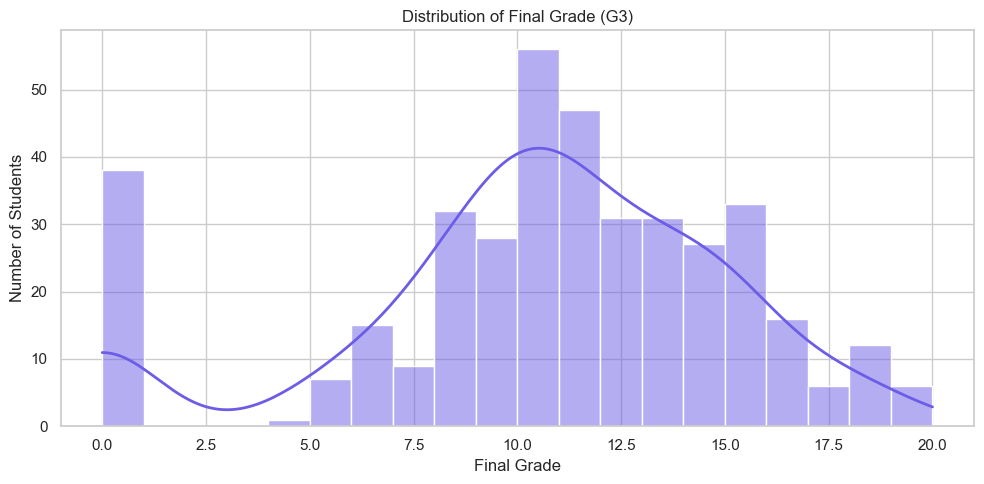

In [13]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="G3",
    bins=20,
    kde=True,
    color="#6C5CE7",
    edgecolor="white",
    line_kws={"color": "#2D3436", "linewidth": 2}
)

plt.title("Distribution of Final Grade (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()


**Observation:** `G3` ranges from **0 to 20**, with a mean of about **10.42** and a median of **11**.  
Most students are concentrated around the middle grades, while **38 students have a final grade of 0**, creating a noticeable spike at zero. The distribution is therefore not perfectly normal.


## 7. Explore categorical features

For each categorical variable, we inspect the number of students in each category.  
This helps us detect rare categories, understand the meaning of the variables, and prepare for categorical encoding later.


In [14]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


school
school
GP    349
MS     46
Name: count, dtype: int64

sex
sex
F    208
M    187
Name: count, dtype: int64

address
address
U    307
R     88
Name: count, dtype: int64

famsize
famsize
GT3    281
LE3    114
Name: count, dtype: int64

Pstatus
Pstatus
T    354
A     41
Name: count, dtype: int64

Mjob
Mjob
other       141
services    103
at_home      59
teacher      58
health       34
Name: count, dtype: int64

Fjob
Fjob
other       217
services    111
teacher      29
at_home      20
health       18
Name: count, dtype: int64

reason
reason
course        145
home          109
reputation    105
other          36
Name: count, dtype: int64

guardian
guardian
mother    273
father     90
other      32
Name: count, dtype: int64

schoolsup
schoolsup
no     344
yes     51
Name: count, dtype: int64

famsup
famsup
yes    242
no     153
Name: count, dtype: int64

paid
paid
no     214
yes    181
Name: count, dtype: int64

activities
activities
yes    201
no     194
Name: count, dtype: int64

nu

**Why this matters for modeling:** Machine-learning algorithms generally require numeric input. These categorical features will later be encoded, most likely with **one-hot encoding** inside a preprocessing pipeline.


## 8. Numerical summary statistics

The transposed `describe()` table makes it easier to compare the range, center, and spread of numerical features.

This step is useful for spotting unusual values and for distinguishing truly numerical variables from ordinal scales.


In [15]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,395.0,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
Medu,395.0,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
famrel,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0
freetime,395.0,3.235443,0.998862,1.0,3.0,3.0,4.0,5.0
goout,395.0,3.108861,1.113278,1.0,2.0,3.0,4.0,5.0
Dalc,395.0,1.481013,0.890741,1.0,1.0,1.0,2.0,5.0


**Observation:** Several features use small ordered scales (for example 1–4 or 1–5), while `absences` has a much wider range and reaches **75**, suggesting the presence of high-absence outliers.


## 9. Inspect unique numerical values

Looking at unique values gives more context than data types alone.  
For example, an integer column containing only `[1, 2, 3, 4]` may represent ordered categories rather than a continuous measurement.


In [16]:
for col in numerical_cols:
    print(col, ":", sorted(df[col].unique()))

age : [np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22)]
Medu : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Fedu : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
traveltime : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
studytime : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
failures : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
famrel : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
freetime : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
goout : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Dalc : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Walc : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
health : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
absences : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.

## 10. Correlation with the target

Correlation measures the strength and direction of a **linear** relationship between numerical variables.

A value close to:
- **+1** indicates a strong positive linear relationship.
- **−1** indicates a strong negative linear relationship.
- **0** indicates little or no linear relationship.

Correlation does **not** prove causation.


In [17]:
correlations = (
    df[numerical_cols]
    .corr()["G3"]
    .sort_values(ascending=False)
)

correlations

G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64

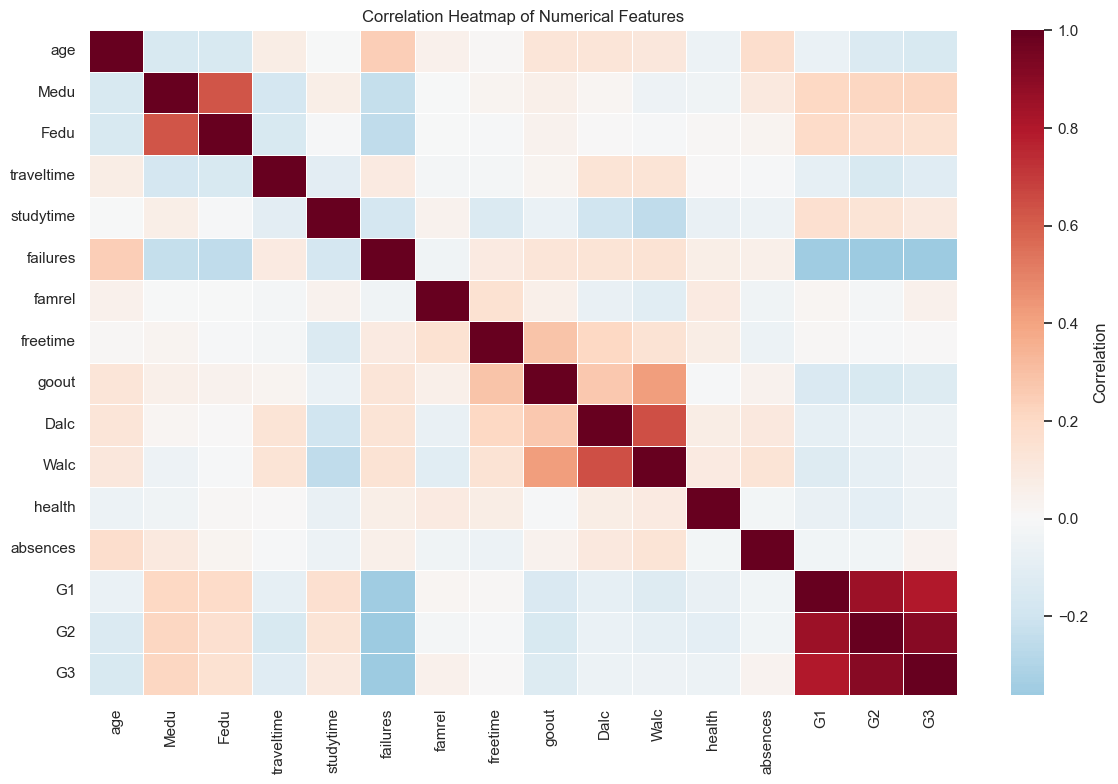

In [18]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[numerical_cols].corr(),
    cmap="RdBu_r",
    center=0,
    linewidths=0.4,
    cbar_kws={"label": "Correlation"}
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()


**Key findings:**
- `G2` has the strongest correlation with `G3` (**0.905**).
- `G1` is also strongly correlated with `G3` (**0.801**).
- `failures` has the strongest negative correlation with `G3` (**−0.360**).
- Most other numerical features have relatively weak linear relationships with the final grade.

These results suggest that previous academic performance will be highly influential in prediction.


## 11. Relationship between `G1`, `G2`, and `G3`

`G1`, `G2`, and `G3` are grades from different periods. Because `G1` and `G2` occur before the final grade, they can be powerful predictors of `G3`.

However, whether they should be included depends on **when the prediction is intended to be made**.


In [19]:
df[["G1", "G2", "G3"]].corr()

,G1,G2,G3
G1,1.000000,0.852118,0.801468
G2,0.852118,1.000000,0.904868
G3,0.801468,0.904868,1.000000


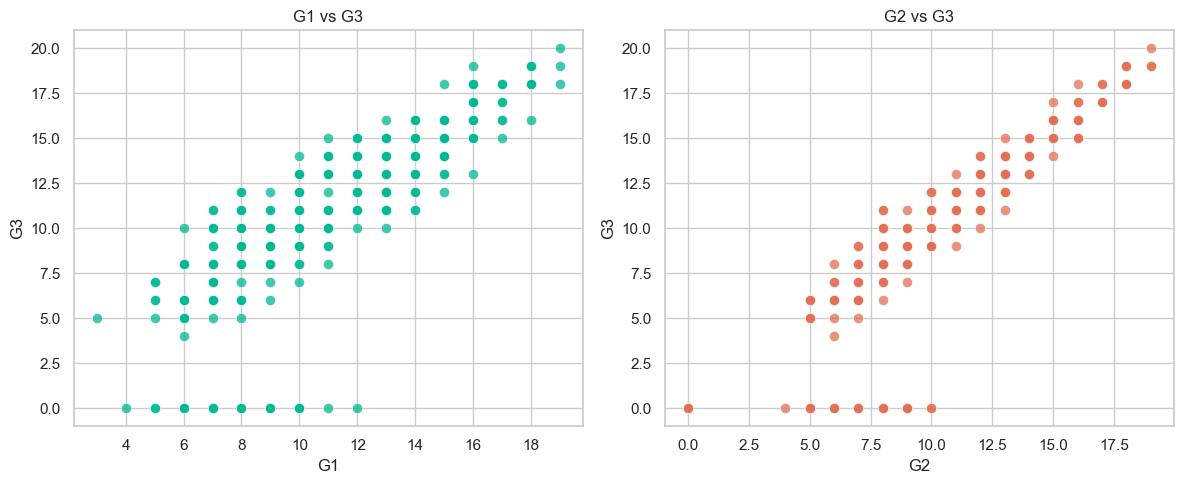

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(
    data=df,
    x="G1",
    y="G3",
    ax=axes[0],
    color="#00B894",
    alpha=0.75,
    s=55
)
axes[0].set_title("G1 vs G3")

sns.scatterplot(
    data=df,
    x="G2",
    y="G3",
    ax=axes[1],
    color="#E17055",
    alpha=0.75,
    s=55
)
axes[1].set_title("G2 vs G3")

plt.tight_layout()
plt.show()


**Observation:** Both earlier grades show a clear positive relationship with the final grade, and `G2` is especially close to `G3`.

### Modeling consideration
We should eventually compare two scenarios:

1. **Late-stage prediction:** include `G1` and `G2` to predict `G3`.
2. **Early-warning prediction:** exclude `G1` and `G2` and rely on demographic, study, family, and school-related information.

This comparison will make the final project more meaningful than simply choosing the model with the highest score.


## 12. Study time vs final grade

A boxplot helps compare the distribution of final grades across the four study-time levels.  
The line inside each box is the median, while the box represents the middle 50% of observations.


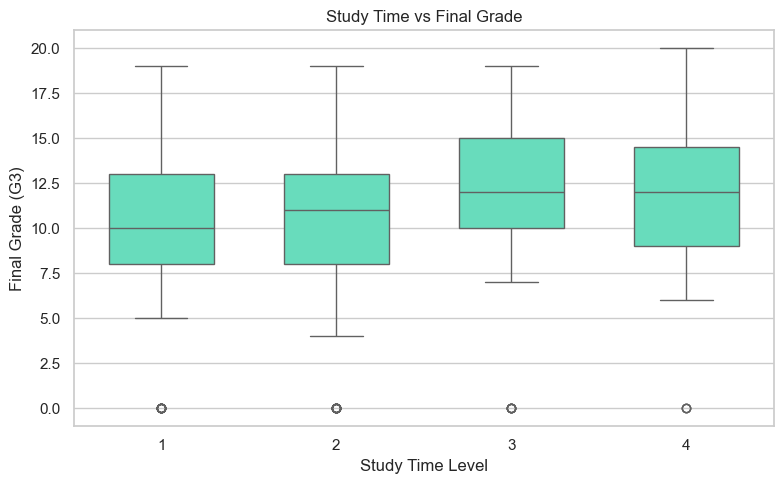

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="studytime",
    y="G3",
    color="#55EFC4",
    width=0.6
)

plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time Level")
plt.ylabel("Final Grade (G3)")
plt.tight_layout()
plt.show()


**Observation:** Students in the higher study-time categories generally show slightly higher median final grades, although the groups overlap substantially.  
This agrees with the weak positive correlation between `studytime` and `G3` (**0.098**): study time may contain useful information, but it is not a strong predictor by itself.


## 13. Previous failures vs final grade

We compare final-grade distributions across the number of previous class failures.  
This feature is especially interesting because the correlation analysis showed a notable negative relationship with `G3`.


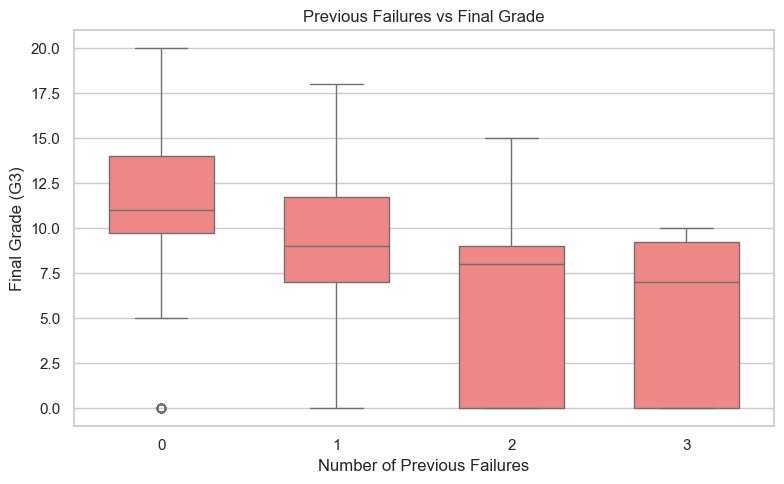

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="failures",
    y="G3",
    color="#FF7675",
    width=0.6
)

plt.title("Previous Failures vs Final Grade")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Final Grade (G3)")
plt.tight_layout()
plt.show()


**Observation:** Final grades tend to decrease as the number of previous failures increases.  
This is consistent with the correlation of approximately **−0.360**, making `failures` one of the more informative non-grade numerical features in the dataset.


## 14. Plans for higher education vs final grade

The `higher` feature indicates whether a student intends to pursue higher education.  
A boxplot lets us compare the grade distributions of students who answered `yes` and `no`.


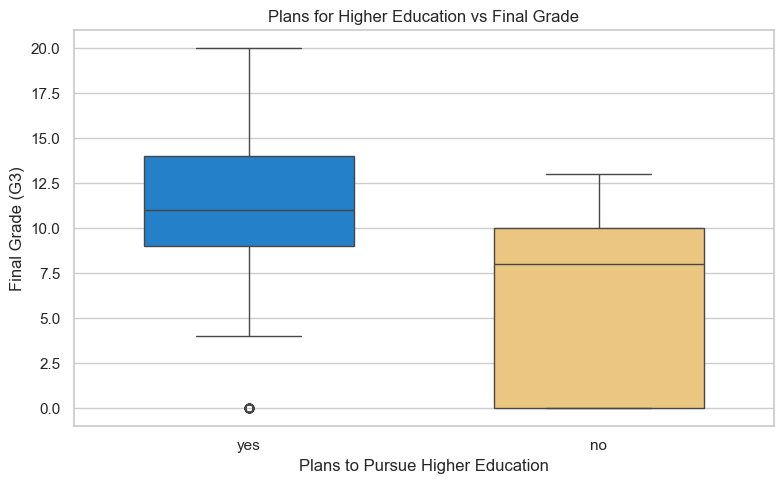

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="higher",
    y="G3",
    hue="higher",
    palette={"yes": "#0984E3", "no": "#FDCB6E"},
    legend=False,
    width=0.6
)

plt.title("Plans for Higher Education vs Final Grade")
plt.xlabel("Plans to Pursue Higher Education")
plt.ylabel("Final Grade (G3)")
plt.tight_layout()
plt.show()


**Observation:** Students who plan to pursue higher education tend to have higher final grades than those who do not.  
This is an **association**, not evidence that the intention itself causes higher performance.


## 15. Absences vs final grade

A scatterplot is useful for checking whether students with more absences tend to receive lower final grades and for identifying unusual observations.


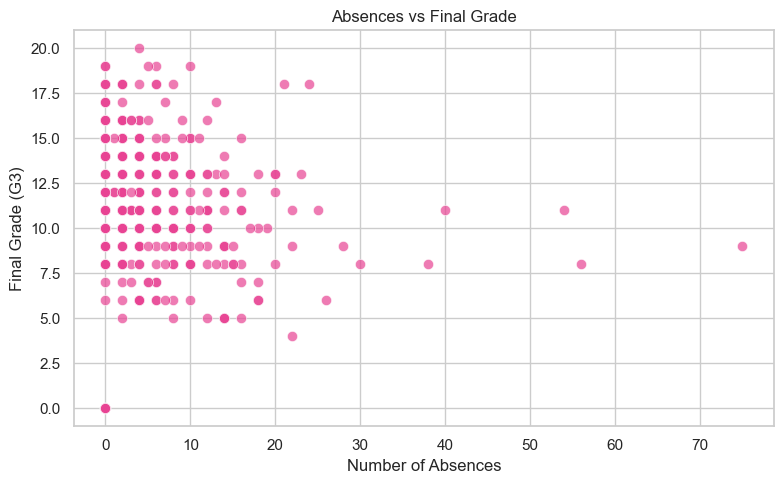

In [24]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="absences",
    y="G3",
    color="#E84393",
    alpha=0.7,
    s=55
)

plt.title("Absences vs Final Grade")
plt.xlabel("Number of Absences")
plt.ylabel("Final Grade (G3)")
plt.tight_layout()
plt.show()


**Observation:** The scatterplot contains several students with unusually high numbers of absences, but the overall linear relationship with `G3` is weak (`r ≈ 0.034`).  
This is a good reminder that an intuitively relevant feature does not necessarily show a strong simple correlation with the target.


# Final EDA Summary

## Dataset quality
- The dataset contains **395 observations and 33 variables**.
- It has **16 numerical** and **17 categorical** columns.
- There are **no missing values**.
- There are **no duplicate rows**.
- Several numerical columns are actually **ordinal scales**, which should be treated thoughtfully during preprocessing.
- `absences` contains a few relatively large values, with a maximum of **75**.

## Target variable
- The prediction target is **`G3`**, the final student grade.
- `G3` ranges from **0 to 20**.
- Mean final grade: **10.42**.
- Median final grade: **11**.
- There are **38 observations with `G3 = 0`**, creating a noticeable spike at zero.

## Most important relationships
- **`G2` → `G3`: 0.905** — very strong positive relationship.
- **`G1` → `G3`: 0.801** — strong positive relationship.
- **`failures` → `G3`: −0.360** — the strongest negative numerical relationship.
- Mother's education (`Medu`) has a modest positive correlation (**0.217**).
- Most remaining numerical variables have weak individual linear correlations with `G3`.
- Higher study time is associated with slightly better grades, but the relationship is weak.
- Students planning to pursue higher education tend to have higher grades in this dataset.
- `absences` contains visible outliers, but its simple linear correlation with `G3` is close to zero.

## Main modeling decision

`G1` and `G2` are extremely predictive of the final grade. Whether we include them should depend on the real-world purpose of the model.

### Model A — Late-stage grade prediction
Use `G1`, `G2`, and the remaining student features.

**Purpose:** predict the final grade once earlier-period grades are already known.

### Model B — Early-warning prediction
Remove `G1` and `G2` and use demographic, family, school, behavioral, and study-related features.

**Purpose:** identify students who may be at risk before strong academic-performance signals are available.

Comparing these two approaches will help us evaluate not only **which model predicts best**, but also **which model would be useful at the intended point in time**.

## Next step
The next stage is **preprocessing**:
1. Separate features (`X`) from target (`y`).
2. Decide how to handle `G1` and `G2`.
3. Encode categorical variables.
4. Build a reproducible preprocessing pipeline.
5. Split the data into training and test sets without leaking information from the test set.
